# Community and Cultural Assets at Risk from Wildfire
**Series:** Tribal Fire Science & Indigenous Data Sovereignty  
**Author:** Lilly Jones, PhD  
**Last Updated:** 2025  
**Data Sources:** Census TIGER AIANNH, MTBS, OpenStreetMap (infrastructure, roads), Census blocks

## Overview
This notebook analyzes exposure of community and cultural assets to wildfire risk
for a single Tribal Nation. It uses privacy-preserving data sovereignty methods throughout:
aggregation and buffering protect sensitive locations, and cultural site analysis
requires explicit Tribal consent and real Tribal-provided data.

**This notebook is designed for single-Tribe use.** Set `TRIBE_OF_INTEREST` in
Section 1 to the Tribal Nation you are analyzing.

## Before Using This Notebook
- Obtain explicit Tribal council approval for data use
- Establish data sharing agreements before analysis begins
- Review all outputs with Tribal cultural officers before sharing
- Never share precise coordinates of cultural or sensitive sites
- Respect Tribal data governance protocols at every step

## Data Notes
| Component | Source | Status |
|---|---|---|
| Tribal boundary | Census TIGER AIANNH | Real |
| Fire risk / history | MTBS | Real |
| Public infrastructure | OpenStreetMap | Real |
| Evacuation roads | OpenStreetMap | Real |
| Census block population | Census TIGER | Real (proxy for housing) |
| Cultural sites | Tribal GIS / consent required | **Schema only; requires Tribal engagement** |
| Fire scenarios | Elliptical spread model | **Illustrative only; not operational** |

In [1]:
# Imports
import sys
from pathlib import Path

REPO_ROOT = Path().resolve().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import json
import warnings
from datetime import datetime

import contextily as ctx
import geopandas as gpd
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import osmnx as ox
import pandas as pd
import seaborn as sns
from shapely import affinity
from shapely.geometry import LineString, Point, box
from shapely.ops import unary_union
from shapely.validation import make_valid

from src.data import constants, loaders, validators
from src.data.constants import PRIMARY_TRIBES
from src.geo import utils as geo_utils
from src.indigenous.sovereignty import generate_citations, print_data_acknowledgment
from src.viz import charts, styles

styles.apply_mpl_style()
%matplotlib inline

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning, module="geopandas")

print(f"Repo root : {REPO_ROOT}")
print(f"Output dir: {constants.OUTPUTS_DIR}")
print(f"Analysis run: {datetime.now().strftime('%Y-%m-%d %H:%M')}")
print("\nREMINDER: Obtain explicit Tribal consent before using sensitive data.")

Repo root : C:\Users\gekek\Documents\tfs_refactor
Output dir: C:\Users\gekek\Documents\tfs_refactor\outputs
Analysis run: 2026-04-17 11:48

REMINDER: Obtain explicit Tribal consent before using sensitive data.


In [2]:
print_data_acknowledgment(source_keys=["census_aiannh", "mtbs"])

DATA SOVEREIGNTY ACKNOWLEDGMENT
This analysis uses data that describes Indigenous and Tribal lands,
communities, and fire histories. This project is guided by four
complementary data governance frameworks:

OCAP® : Tribal Nations own, control, access, and possess data about
  their own communities and territories.
  Reference: https://fnigc.ca/ocap-training/

CARE  : Data use must deliver Collective Benefit to Indigenous peoples,
  respect their Authority to Control, uphold Responsibility to communities,
  and center Ethics across the full data lifecycle.
  Reference: https://www.gida-global.org/care

FAIR  : Data is Findable, Accessible, Interoperable, and Reusable.
  FAIR governs technical standards; CARE and OCAP® govern the ethical
  obligations to Tribal Nations that FAIR alone does not address.
  Reference: https://www.go-fair.org/fair-principles/

IEEE 2890-2025: Recommended Practice for Provenance of Indigenous Peoples' Data
 The first international standard for Indigenous data

## Configure 

In [3]:
# Select Tribal Nation for this analysis by
# Changing TRIBE_OF_INTEREST to any name from PRIMARY_TRIBES.
# This notebook is designed for single-Tribe analysis because it requires
# Tribal consent for sensitive data that is specific to each Nation.

# Can change to the Tribal Nation you are analyzing
TRIBE_OF_INTEREST = "Fort Apache"  

assert TRIBE_OF_INTEREST in PRIMARY_TRIBES, (
    f"{TRIBE_OF_INTEREST!r} not in PRIMARY_TRIBES. "
    f"Valid options: {PRIMARY_TRIBES}"
)

#  Privacy framework
PRIVACY_LEVELS = {
    "public": {
        "description":          "Public infrastructure (schools, clinics, fire stations)",
        "buffer_distance_m":    0,
        "show_exact_location":  True,
        "aggregation_required": False,
    },
    "sensitive": {
        "description":          "Residences, gathering places",
        "buffer_distance_m":    500,
        "show_exact_location":  False,
        "aggregation_required": True,
    },
    "highly_sensitive": {
        "description":             "Cultural/sacred sites",
        "buffer_distance_m":       1000,
        "show_exact_location":     False,
        "aggregation_required":    True,
        "tribal_consent_required": True,
    },
}

ANALYSIS_CONFIG = {
    "evacuation_buffer_m":  100,   # Buffer either side of route for risk assessment
    "minimum_aggregation":  3,     # Min features before showing aggregated zone
    "scenario_buffer_km":   0.5,   # Buffer around tribal boundary for OSM queries
}

print(f"Analysis target : {TRIBE_OF_INTEREST}")
print("\nPrivacy protection levels:")
for level, cfg in PRIVACY_LEVELS.items():
    consent = " TRIBAL CONSENT REQUIRED" if cfg.get("tribal_consent_required") else ""
    print(f"  {level.upper()}: {cfg['description']}, {cfg['buffer_distance_m']}m buffer{consent}")

Analysis target : Fort Apache

Privacy protection levels:
  PUBLIC: Public infrastructure (schools, clinics, fire stations), 0m buffer
  SENSITIVE: Residences, gathering places, 500m buffer
  HIGHLY_SENSITIVE: Cultural/sacred sites, 1000m buffer TRIBAL CONSENT REQUIRED


## Load Tribal Boundary and Fire History

In [4]:
# Tribal boundary
all_tribal = loaders.load_census_aian()
all_tribal = validators.validate_geodataframe(
    all_tribal, "census_aiannh", required_columns=["geometry", "NAME"]
)
tribe_gdf = all_tribal[all_tribal["NAME"] == TRIBE_OF_INTEREST].copy()
tribe_gdf = tribe_gdf.dissolve(by="NAME", as_index=False)
tribe_gdf["geometry"] = tribe_gdf.geometry.apply(
    lambda g: make_valid(g) if g is not None else g
)
tribe_geom = tribe_gdf.geometry.iloc[0]

tribe_proj   = tribe_gdf.to_crs("EPSG:5070")
area_acres   = tribe_proj.geometry.area.iloc[0] / 4047
bounds       = tribe_gdf.total_bounds
BUF          = ANALYSIS_CONFIG["scenario_buffer_km"] / 111  # degrees
QUERY_BBOX   = (bounds[0]-BUF, bounds[1]-BUF, bounds[2]+BUF, bounds[3]+BUF)

print(f"Tribal Nation : {TRIBE_OF_INTEREST}")
print(f"Area          : {area_acres:,.0f} acres")
print(f"Query bbox    : {tuple(round(x, 3) for x in QUERY_BBOX)}")

Tribal Nation : Fort Apache
Area          : 1,683,943 acres
Query bbox    : (np.float64(-110.788), np.float64(33.471), np.float64(-109.49), np.float64(34.312))


In [5]:
# Fire risk from MTBS
MTBS_LOCAL = constants.RAW_DIR /"mtbs_perimeters"/"mtbs_perims_DD.shp"
GRID_DEG   = 0.05

if MTBS_LOCAL.exists():
    fire_gdf = gpd.read_file(MTBS_LOCAL)
    fire_gdf.columns = fire_gdf.columns.str.lower()
    fire_gdf["ig_date"]   = pd.to_datetime(fire_gdf["ig_date"], errors="coerce")
    fire_gdf["fire_year"] = fire_gdf["ig_date"].dt.year
    fire_gdf = fire_gdf.to_crs(constants.CRS_GEOGRAPHIC)

    # Clip to study area
    clip_poly = geo_utils.bbox_geodataframe(QUERY_BBOX).geometry.iloc[0]
    local_fires = fire_gdf[fire_gdf.intersects(clip_poly)].copy()

    # Build fire frequency grid
    xs   = np.arange(bounds[0], bounds[2], GRID_DEG)
    ys   = np.arange(bounds[1], bounds[3], GRID_DEG)
    grid_records = []
    for x in xs:
        for y in ys:
            cell = box(x, y, x + GRID_DEG, y + GRID_DEG)
            if not tribe_geom.intersects(cell):
                continue
            n_fires = local_fires[local_fires.intersects(cell)].shape[0]
            grid_records.append({"geometry": cell, "fire_count": n_fires})

    fire_risk_grid = gpd.GeoDataFrame(grid_records, crs=constants.CRS_GEOGRAPHIC)
    max_count = fire_risk_grid["fire_count"].max()
    if max_count > 0:
        fire_risk_grid["risk_score"] = (fire_risk_grid["fire_count"] / max_count * 10).round(2)
    else:
        fire_risk_grid["risk_score"] = 0.0
    fire_risk_grid["risk_level"] = pd.cut(
        fire_risk_grid["risk_score"],
        bins=[-0.01, 3, 6, 10],
        labels=["Low", "Moderate", "High"],
    )
    MTBS_AVAILABLE = True
    print(f"MTBS fire risk grid built: {len(fire_risk_grid):,} cells")
    print(fire_risk_grid["risk_level"].value_counts().to_string())
else:
    # Fallback grid with uniform moderate risk 
    xs   = np.arange(bounds[0], bounds[2], GRID_DEG)
    ys   = np.arange(bounds[1], bounds[3], GRID_DEG)
    grid_records = [
        {"geometry": box(x, y, x+GRID_DEG, y+GRID_DEG),
         "fire_count": 0, "risk_score": 5.0, "risk_level": "Moderate"}
        for x in xs for y in ys
        if tribe_geom.intersects(box(x, y, x+GRID_DEG, y+GRID_DEG))
    ]
    fire_risk_grid = gpd.GeoDataFrame(grid_records, crs=constants.CRS_GEOGRAPHIC)
    MTBS_AVAILABLE = False
    print(
        "MTBS not found: fire risk grid using neutral placeholder (5.0).\n"
        "  Download from https://www.mtbs.gov and place in data/raw/mtbs_perimeters/"
    )

MTBS fire risk grid built: 311 cells
risk_level
Low         265
Moderate     33
High         13


## Load Community Infrastructure from OSM

In [24]:
# Public infrastructure from OSM 
# Queries OSM amenity tags within the Tribal land bounding box.
# OSM coverage varies; some Tribal facilities may be missing or miscategorized.
# Verify results with Tribal GIS department.

ox.settings.log_console = False
ox.settings.use_cache   = True

PUBLIC_TAGS = {
    "amenity": [
        "school", "college", "university",
        "hospital", "clinic", "health_centre",
        "community_centre", "social_centre",
        "fire_station",
        "government", "townhall",
        "water_tower",
    ]
}

# Human-readable type labels
AMENITY_TYPE_MAP = {
    "school":           "School",
    "college":          "School",
    "university":       "School",
    "hospital":         "Health Clinic",
    "clinic":           "Health Clinic",
    "health_centre":    "Health Clinic",
    "community_centre": "Community Center",
    "social_centre":    "Community Center",
    "fire_station":     "Fire Station",
    "government":       "Tribal Office",
    "townhall":         "Tribal Office",
    "water_tower":      "Water Tank",
}

try:
    raw_infra = ox.features_from_bbox(
        bbox=QUERY_BBOX,
        tags=PUBLIC_TAGS,
    )
    # Convert polygons to centroids using projected CRS for accuracy
    raw_infra = raw_infra.copy()
    raw_infra["geometry"] = (
        raw_infra.to_crs("EPSG:5070")
        .geometry.centroid
        .to_crs("EPSG:4326")
    )
    raw_infra = gpd.GeoDataFrame(raw_infra, geometry="geometry",
                                  crs=constants.CRS_GEOGRAPHIC)
    raw_infra = raw_infra[
        raw_infra.geometry.notnull() & ~raw_infra.geometry.is_empty
    ].reset_index(drop=True)
    
    # Clip to Tribal land
    raw_infra = raw_infra[raw_infra.within(tribe_geom)].copy().reset_index(drop=True)

    # Normalize type column
    amenity_col = raw_infra["amenity"] if "amenity" in raw_infra.columns else pd.Series(dtype=str)
    raw_infra["type"]          = amenity_col.map(AMENITY_TYPE_MAP).fillna("Other")
    raw_infra["privacy_level"] = "public"
    raw_infra["population"]    = 0  # OSM does not carry population
    raw_infra["feature_id"]    = [
        f"OSM_{i:04d}" for i in range(len(raw_infra))
    ]
    # Keep only relevant columns
    community_assets = raw_infra[
        ["feature_id", "type", "privacy_level", "population", "geometry"]
    ].copy()

    print(f"Public infrastructure loaded from OSM: {len(community_assets):,} features")
    print(community_assets["type"].value_counts().to_string())

    if community_assets.empty:
        print("\nNo OSM features found within Tribal boundary.")
        print("OSM coverage may be incomplete for this area.")
        print("Contact Tribal GIS department for authoritative facility locations.")
except Exception as e:
    print(f"OSM infrastructure query failed: {e}")
    community_assets = gpd.GeoDataFrame(
        columns=["feature_id", "type", "privacy_level", "population", "geometry"],
        geometry="geometry", crs=constants.CRS_GEOGRAPHIC,
    )

Public infrastructure loaded from OSM: 21 features
type
School              13
Fire Station         4
Community Center     2
Tribal Office        1
Health Clinic        1


## Cultural Sites

> **REQUIRES TRIBAL CONSENT AND DIRECT TRIBAL ENGAGEMENT**
> 
> Cultural site locations are not available from any public source and must
> never be inferred, estimated, or fabricated. Only load real data here
> with documented Tribal council approval.
> 
> Sources for real data:
> - Tribal Cultural Preservation Office (primary and authoritative)
> - Tribal Historic Preservation Officer (THPO)
> - State Historic Preservation Office (with Tribal consent)
> - BIA (with Tribal consent: Tribal data sovereignty applies)
> 
> Privacy protections applied when data is loaded:
> - 1 km spatial buffer applied to all points
> - Exact locations never exported
> - Outputs show generalized zones only

In [7]:
# Cultural sites:REQUIRES TRIBAL CONSENT
# Set CONSENT_OBTAINED = True only when explicit Tribal council approval is documented.
# Populate CULTURAL_SITE_DATA with real Tribal-provided data.
# NEVER set CONSENT_OBTAINED = True with fake or estimated data.

CONSENT_OBTAINED   = False  # DO NOT change to True without actual Tribal consent
CONSENT_DATE       = None   # ex. "2025-06-15" when consent is obtained
CONSENT_AUTHORITY  = None   # ex. "Fort Apache Tribal Council Resolution 2025-42"

# Schema: populate with real Tribal-provided data
CULTURAL_SITE_DATA = [
    # {
    #     "site_id":       "CULTURAL_001",  # Anonymized ID: never use true site name
    #     "type_general":  "Cultural Site",  # Generalized: never type_specific in output
    #     "privacy_level": "highly_sensitive",
    #     "geometry":      Point(lon, lat),  # From Tribal GIS
    # }
]

if CONSENT_OBTAINED and CULTURAL_SITE_DATA:
    cultural_sites = gpd.GeoDataFrame(
        CULTURAL_SITE_DATA, crs=constants.CRS_GEOGRAPHIC
    )
    print(f"Cultural sites loaded: {len(cultural_sites)}")
    print(f"Consent authority : {CONSENT_AUTHORITY}")
    print(f"Consent date      : {CONSENT_DATE}")
    print("All outputs will use 1 km spatial buffers and generalized zones only.")
elif not CONSENT_OBTAINED:
    cultural_sites = gpd.GeoDataFrame(
        columns=["site_id", "type_general", "privacy_level", "geometry"],
        geometry="geometry", crs=constants.CRS_GEOGRAPHIC,
    )
    print(
        "Cultural site analysis disabled: Tribal consent not obtained.\n"
        "Contact the Tribal Cultural Preservation Office or THPO to establish\n"
        "a data sharing agreement before enabling this section."
    )
else:
    cultural_sites = gpd.GeoDataFrame(
        columns=["site_id", "type_general", "privacy_level", "geometry"],
        geometry="geometry", crs=constants.CRS_GEOGRAPHIC,
    )
    print("Consent obtained but no site data provided. Populate CULTURAL_SITE_DATA.")

Cultural site analysis disabled: Tribal consent not obtained.
Contact the Tribal Cultural Preservation Office or THPO to establish
a data sharing agreement before enabling this section.


## Evacuation Routes from OSM

In [8]:
# Evacuation routes (OSM road network)
# Downloads the drivable road network within the Tribal land bounding box.
# Primary roads (highway, trunk, primary) are used as evacuation route proxies.
# Verify with Tribal emergency management for official evacuation routes.

try:
    G = ox.graph_from_bbox(
        bbox=QUERY_BBOX,
        network_type="drive",
        simplify=True,
    )
    _, edges = ox.graph_to_gdfs(G)
    edges = edges.to_crs(constants.CRS_GEOGRAPHIC).reset_index(drop=True)

    # Classify by highway tag
    PRIMARY_HWY = {"motorway", "trunk", "primary", "secondary"}

    def _route_type(hw):
        if isinstance(hw, list):
            hw = hw[0] if hw else ""
        return "Primary" if hw in {"motorway", "trunk", "primary"} else "Secondary"

    def _capacity(hw):
        if isinstance(hw, list):
            hw = hw[0] if hw else ""
        return 1200 if hw in {"motorway", "trunk", "primary"} else 400

    edges["route_type"]  = edges["highway"].apply(_route_type)
    edges["capacity_vph"] = edges["highway"].apply(_capacity)

    # Keep only primary/secondary roads as named evacuation routes
    evacuation_routes = edges[
        edges["highway"].apply(
            lambda h: (h[0] if isinstance(h, list) else h) in PRIMARY_HWY
        )
    ].copy().reset_index(drop=True)
    evacuation_routes["route_id"] = [
        f"RTE_{i:04d}" for i in range(len(evacuation_routes))
    ]
    # Use OSM name if available
    if "name" in evacuation_routes.columns:
        evacuation_routes["name"] = evacuation_routes["name"].fillna(
            evacuation_routes["route_id"]
        )
    else:
        evacuation_routes["name"] = evacuation_routes["route_id"]

    print(f"Evacuation routes loaded from OSM: {len(evacuation_routes):,} segments")
    print(evacuation_routes["route_type"].value_counts().to_string())
    total_cap = evacuation_routes["capacity_vph"].sum()
    print(f"Total capacity (estimated): {total_cap:,} vehicles/hour")

except Exception as e:
    print(f"OSM road network query failed: {e}")
    evacuation_routes = gpd.GeoDataFrame(
        columns=["route_id", "name", "route_type", "capacity_vph", "geometry"],
        geometry="geometry", crs=constants.CRS_GEOGRAPHIC,
    )

Evacuation routes loaded from OSM: 864 segments
route_type
Primary      482
Secondary    382
Total capacity (estimated): 731,200 vehicles/hour


In [9]:
# Evacuation route vulnerability
def assess_route_vulnerability(
    routes: gpd.GeoDataFrame,
    risk_grid: gpd.GeoDataFrame,
    buffer_m: int = 100,
) -> pd.DataFrame:
    """Assess % of each route segment in high/moderate risk zones."""
    routes_m = routes.to_crs("EPSG:5070")
    risk_m   = risk_grid.to_crs("EPSG:5070")
    results  = []
    for _, route in routes_m.iterrows():
        buf      = route.geometry.buffer(buffer_m)
        overlap  = risk_m[risk_m.intersects(buf)]
        total_km = route.geometry.length / 1000
        hi_km, mo_km = 0.0, 0.0
        for lvl in ["High", "Moderate"]:
            zones = overlap[overlap["risk_level"] == lvl]
            if not zones.empty:
                inter = route.geometry.intersection(zones.union_all())
                length = inter.length / 1000 if not inter.is_empty else 0
                if lvl == "High": hi_km = length
                else:             mo_km = length
        vuln = (hi_km / total_km * 200 + mo_km / total_km * 100) if total_km > 0 else 0
        results.append({
            "route_id":           route["route_id"],
            "name":               route.get("name", route["route_id"]),
            "route_type":         route["route_type"],
            "total_km":           round(total_km, 2),
            "high_risk_km":       round(hi_km, 2),
            "moderate_risk_km":   round(mo_km, 2),
            "high_risk_pct":      round(hi_km / total_km * 100, 1) if total_km > 0 else 0,
            "moderate_risk_pct":  round(mo_km / total_km * 100, 1) if total_km > 0 else 0,
            "vulnerability_score": round(vuln, 1),
            "capacity_vph":       route["capacity_vph"],
        })
    return pd.DataFrame(results)


if not evacuation_routes.empty:
    # Normalize OSM list-valued columns before assessment
    for col in ["name", "route_type", "highway"]:
        if col in evacuation_routes.columns:
            evacuation_routes[col] = evacuation_routes[col].apply(
                lambda v: v[0] if isinstance(v, list) else str(v) if pd.notna(v) else "Unknown"
            )

    route_assessment = assess_route_vulnerability(
        evacuation_routes, fire_risk_grid,
        buffer_m=ANALYSIS_CONFIG["evacuation_buffer_m"],
    )
    critical = route_assessment[route_assessment["vulnerability_score"] > 50]
    print(f"Routes assessed: {len(route_assessment)}")
    print(f"Critical (score > 50): {len(critical)}")
    print(route_assessment[["name", "route_type", "high_risk_pct",
                             "vulnerability_score"]].head(10).to_string(index=False))
else:
    route_assessment = pd.DataFrame()
    print("No evacuation routes: vulnerability assessment skipped.")

Routes assessed: 864
Critical (score > 50): 30
                  name route_type  high_risk_pct  vulnerability_score
Globe-Show Low Highway    Primary            0.0                  0.0
Globe-Show Low Highway    Primary            0.0                  0.0
Globe-Show Low Highway    Primary            0.0                  0.0
Globe-Show Low Highway    Primary            0.0                  0.0
Globe-Show Low Highway    Primary            0.0                  0.0
Globe-Show Low Highway    Primary            0.0                  0.0
Globe-Show Low Highway    Primary            0.0                  0.0
Globe-Show Low Highway    Primary            0.0                  0.0
Globe-Show Low Highway    Primary            0.0                  0.0
Globe-Show Low Highway    Primary            0.0                  0.0


Figure saved C:\Users\gekek\Documents\tfs_refactor\outputs\figures\evacuation_route_vulnerability.png


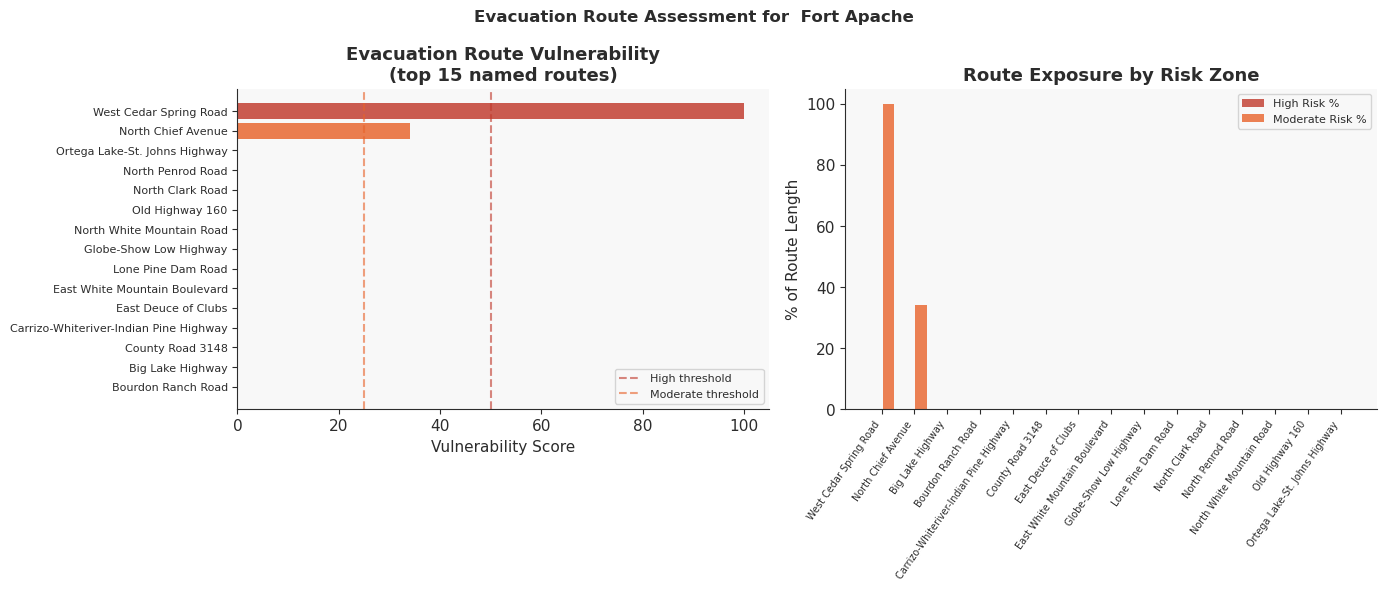

In [10]:
if not route_assessment.empty:
    # Aggregate to named routes where OSM edges are individual segments
    route_summary = (
        route_assessment.groupby("name")
        .agg(
            route_type=("route_type", "first"),
            total_km=("total_km", "sum"),
            high_risk_km=("high_risk_km", "sum"),
            moderate_risk_km=("moderate_risk_km", "sum"),
            capacity_vph=("capacity_vph", "first"),
        )
        .reset_index()
    )
    route_summary["high_risk_pct"]    = (route_summary["high_risk_km"]    / route_summary["total_km"] * 100).round(1)
    route_summary["moderate_risk_pct"] = (route_summary["moderate_risk_km"] / route_summary["total_km"] * 100).round(1)
    route_summary["vulnerability_score"] = (
    route_summary["high_risk_pct"] * 2 + route_summary["moderate_risk_pct"]
    ).round(1)

    # Keep top 15 by vulnerability score to keep chart readable
    route_summary = route_summary.nlargest(15, "vulnerability_score")

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, max(6, len(route_summary) * 0.4)))

    s = route_summary.sort_values("vulnerability_score", ascending=True)
    ax1.barh(
        s["name"], s["vulnerability_score"],
        color=[
            styles.EMBER_RED   if v > 50 else
            styles.FIRE_ORANGE if v > 25 else
            styles.SAGE_GREEN
            for v in s["vulnerability_score"]
        ],
        alpha=0.82,
    )
    ax1.axvline(50, color=styles.EMBER_RED,   linestyle="--", alpha=0.6, label="High threshold")
    ax1.axvline(25, color=styles.FIRE_ORANGE, linestyle="--", alpha=0.6, label="Moderate threshold")
    ax1.set_xlabel("Vulnerability Score")
    ax1.set_title("Evacuation Route Vulnerability\n(top 15 named routes)", fontweight="bold")
    ax1.legend(fontsize=8)
    ax1.tick_params(axis="y", labelsize=8)
    sns.despine(ax=ax1)

    s2 = route_summary.sort_values("high_risk_pct", ascending=False)
    x   = np.arange(len(s2))
    ax2.bar(x - 0.2, s2["high_risk_pct"],     0.35, label="High Risk %",     color=styles.EMBER_RED,   alpha=0.8)
    ax2.bar(x + 0.2, s2["moderate_risk_pct"], 0.35, label="Moderate Risk %", color=styles.FIRE_ORANGE, alpha=0.8)
    ax2.set_xticks(x)
    ax2.set_xticklabels(s2["name"], rotation=55, ha="right", fontsize=7)
    ax2.set_ylabel("% of Route Length")
    ax2.set_title("Route Exposure by Risk Zone", fontweight="bold")
    ax2.legend(fontsize=8)
    sns.despine(ax=ax2)

    plt.suptitle(f"Evacuation Route Assessment for  {TRIBE_OF_INTEREST}",
                 fontsize=12, fontweight="bold")
    plt.tight_layout()
    charts.save_figure(fig, "outputs/figures/evacuation_route_vulnerability.png")
    plt.show()


## Privacy Buffers and Aggregation

In [11]:
# Apply privacy buffers 
def apply_privacy_buffers(
    gdf: gpd.GeoDataFrame,
    privacy_config: dict,
) -> gpd.GeoDataFrame:
    """Buffer sensitive point features by their required privacy distance."""
    out = gdf.to_crs("EPSG:5070").copy()
    for idx, row in out.iterrows():
        dist = privacy_config.get(row["privacy_level"], {}).get("buffer_distance_m", 0)
        if dist > 0:
            out.at[idx, "geometry"] = row.geometry.buffer(dist)
        out.at[idx, "buffered"]          = dist > 0
        out.at[idx, "buffer_distance_m"] = dist
    return out.to_crs(constants.CRS_GEOGRAPHIC)


def aggregate_to_grid(
    gdf: gpd.GeoDataFrame,
    grid_size_km: float = 5,
    min_count: int = 3,
) -> gpd.GeoDataFrame:
    """Aggregate point features into grid cells to protect precise locations."""
    gdf_proj = gdf.to_crs("EPSG:5070")
    gs       = grid_size_km * 1000
    b        = gdf_proj.total_bounds
    xmin     = np.floor(b[0] / gs) * gs
    ymin     = np.floor(b[1] / gs) * gs
    xmax     = np.ceil(b[2]  / gs) * gs
    ymax     = np.ceil(b[3]  / gs) * gs
    cells    = []
    for x in np.arange(xmin, xmax, gs):
        for y in np.arange(ymin, ymax, gs):
            cell  = box(x, y, x + gs, y + gs)
            count = gdf_proj[gdf_proj.intersects(cell)].shape[0]
            if count >= min_count:
                cells.append({
                    "feature_count":  count,
                    "count_category": "3-5" if count < 6 else "6-10" if count < 11 else "10+",
                    "geometry":       cell,
                })
    if not cells:
        return gpd.GeoDataFrame(
            columns=["feature_count", "count_category", "geometry"],
            geometry="geometry", crs=constants.CRS_GEOGRAPHIC,
        )
    return gpd.GeoDataFrame(cells, crs="EPSG:5070").to_crs(constants.CRS_GEOGRAPHIC)


if not community_assets.empty:
    community_buffered = apply_privacy_buffers(community_assets, PRIVACY_LEVELS)
    print(f"Community assets with privacy buffers: {community_buffered['buffered'].sum()}")
else:
    community_buffered = community_assets.copy()

if not cultural_sites.empty:
    cultural_buffered   = apply_privacy_buffers(cultural_sites, PRIVACY_LEVELS)
    cultural_aggregated = aggregate_to_grid(
        cultural_sites, grid_size_km=5,
        min_count=ANALYSIS_CONFIG["minimum_aggregation"],
    )
    print(f"Cultural sites aggregated into {len(cultural_aggregated)} grid cells")
else:
    cultural_buffered   = cultural_sites.copy()
    cultural_aggregated = gpd.GeoDataFrame(
        columns=["feature_count", "count_category", "geometry"],
        geometry="geometry", crs=constants.CRS_GEOGRAPHIC,
    )
    print("No cultural site data: aggregation skipped.")

Community assets with privacy buffers: 0
No cultural site data: aggregation skipped.


## Fire Risk Exposure Analysis

In [12]:
# Asset exposure to fire risk 
def calculate_asset_exposure(
    assets: gpd.GeoDataFrame,
    risk_grid: gpd.GeoDataFrame,
) -> pd.DataFrame:
    """Join each asset to overlapping risk grid cells and return max risk score."""
    results = []
    for idx, asset in assets.iterrows():
        overlap = risk_grid[risk_grid.intersects(asset.geometry)]
        if not overlap.empty:
            max_score = overlap["risk_score"].max()
            risk_lvl  = overlap.loc[overlap["risk_score"].idxmax(), "risk_level"]
        else:
            max_score = 0.0
            risk_lvl  = "Unknown"
        results.append({
            "feature_id":    asset.get("feature_id", f"ASSET_{idx}"),
            "type":          asset.get("type", "Unknown"),
            "privacy_level": asset["privacy_level"],
            "population":    asset.get("population", 0),
            "risk_level":    str(risk_lvl),
            "risk_score":    max_score,
        })
    return pd.DataFrame(results)


if not community_assets.empty:
    community_exposure = calculate_asset_exposure(community_assets, fire_risk_grid)
    print("COMMUNITY ASSET EXPOSURE")
    print(community_exposure["risk_level"].value_counts().to_string())
    high_risk = community_exposure[community_exposure["risk_level"] == "High"]
    print(f"\nHigh-risk assets: {len(high_risk)}")
    if len(high_risk) > 0 and "type" in high_risk.columns:
        print(high_risk.groupby("type")["feature_id"].count().to_string())
else:
    community_exposure = pd.DataFrame()
    print("No community assets loaded: exposure analysis skipped.")

# Cultural sites aggregated summary only, never site-specific
if not cultural_sites.empty:
    cultural_exposure = calculate_asset_exposure(cultural_sites, fire_risk_grid)
    print("\nCULTURAL SITE EXPOSURE (aggregated summary: no site-specific info)")
    print(cultural_exposure["risk_level"].value_counts().to_string())
    print("No site-specific information disclosed.")
else:
    cultural_exposure = pd.DataFrame()

COMMUNITY ASSET EXPOSURE
risk_level
Low         17
Moderate     3
High         1

High-risk assets: 1
type
Fire Station    1


In [22]:
# Evacuation route vulnerability 
def assess_route_vulnerability(
    routes: gpd.GeoDataFrame,
    risk_grid: gpd.GeoDataFrame,
    buffer_m: int = 100,
) -> pd.DataFrame:
    """Assess % of each route segment in high/moderate risk zones."""
    routes_m   = routes.to_crs("EPSG:5070")
    risk_m     = risk_grid.to_crs("EPSG:5070")
    results    = []
    for _, route in routes_m.iterrows():
        buf        = route.geometry.buffer(buffer_m)
        overlap    = risk_m[risk_m.intersects(buf)]
        total_km   = route.geometry.length / 1000
        hi_km, mo_km = 0.0, 0.0
        for lvl in ["High", "Moderate"]:
            zones = overlap[overlap["risk_level"] == lvl]
            if not zones.empty:
                inter  = route.geometry.intersection(zones.union_all())
                length = inter.length / 1000 if not inter.is_empty else 0
                if lvl == "High":     hi_km = length
                else:                 mo_km = length
        vuln = (hi_km / total_km * 200 + mo_km / total_km * 100) if total_km > 0 else 0
        results.append({
            "route_id":       route["route_id"],
            "name":           route.get("name", route["route_id"]),
            "route_type":     route["route_type"],
            "total_km":       round(total_km, 2),
            "high_risk_km":   round(hi_km, 2),
            "moderate_risk_km": round(mo_km, 2),
            "high_risk_pct":  round(hi_km / total_km * 100, 1) if total_km > 0 else 0,
            "moderate_risk_pct": round(mo_km / total_km * 100, 1) if total_km > 0 else 0,
            "vulnerability_score": round(vuln, 1),
            "capacity_vph":   route["capacity_vph"],
        })
    return pd.DataFrame(results)

# Normalize OSM list-valued columns to scalar strings
for col in ["name", "route_type", "highway"]:
    if col in route_assessment.columns:
        route_assessment[col] = route_assessment[col].apply(
            lambda v: v[0] if isinstance(v, list) else str(v) if pd.notna(v) else "Unknown"
        )

if not evacuation_routes.empty:
    route_assessment = assess_route_vulnerability(
        evacuation_routes, fire_risk_grid,
        buffer_m=ANALYSIS_CONFIG["evacuation_buffer_m"],
    )
    critical = route_assessment[route_assessment["vulnerability_score"] > 50]
    print(f"Routes assessed: {len(route_assessment)}")
    print(f"Critical (score > 50): {len(critical)}")
    print(route_assessment[["name", "route_type", "high_risk_pct",
                             "vulnerability_score"]].head(10).to_string(index=False))
else:
    route_assessment = pd.DataFrame()
    print("No evacuation routes: vulnerability assessment skipped.")

Routes assessed: 864
Critical (score > 50): 30
                  name route_type  high_risk_pct  vulnerability_score
Globe-Show Low Highway    Primary            0.0                  0.0
Globe-Show Low Highway    Primary            0.0                  0.0
Globe-Show Low Highway    Primary            0.0                  0.0
Globe-Show Low Highway    Primary            0.0                  0.0
Globe-Show Low Highway    Primary            0.0                  0.0
Globe-Show Low Highway    Primary            0.0                  0.0
Globe-Show Low Highway    Primary            0.0                  0.0
Globe-Show Low Highway    Primary            0.0                  0.0
Globe-Show Low Highway    Primary            0.0                  0.0
Globe-Show Low Highway    Primary            0.0                  0.0


## Fire Scenario Planning
> **Illustrative planning tool only.**
> This elliptical spread model is for scenario planning and education.
> For operational fire management, use FARSITE, FlamMap, or FSPro with
> real fuel, weather, and topography inputs.

In [21]:
# Elliptical fire spread model (FOR ILLUSTRATION PURPOSES ONLY)
def model_fire_scenario(
    ignition_lon: float,
    ignition_lat: float,
    wind_direction_deg: float,
    spread_rate_mph: float,
    duration_hours: float,
    scenario_name: str,
) -> gpd.GeoDataFrame:
    """
    Simple elliptical fire spread model for scenario planning.
    Head fire (downwind) 1.0x, flanks 0.3x spread rate.
    NOT suitable for operational fire management.
    """
    ignition_proj = gpd.GeoSeries(
        [Point(ignition_lon, ignition_lat)], crs=constants.CRS_GEOGRAPHIC
    ).to_crs("EPSG:5070").iloc[0]

    spread_m = spread_rate_mph * 1609.34 * duration_hours
    circle   = ignition_proj.buffer(spread_m)
    ellipse  = affinity.scale(circle, xfact=1.0, yfact=0.3)
    ellipse  = affinity.rotate(ellipse, wind_direction_deg, origin=ignition_proj)

    return gpd.GeoDataFrame(
        [{
            "scenario_name":    scenario_name,
            "spread_rate_mph":  spread_rate_mph,
            "duration_hours":   duration_hours,
            "wind_direction":   wind_direction_deg,
            "area_hectares":    round(ellipse.area / 10000, 0),
        }],
        geometry=[ellipse],
        crs="EPSG:5070",
    ).to_crs(constants.CRS_GEOGRAPHIC)


# Use Tribal land centroid as reference for ignition points
centroid = tribe_gdf.to_crs("EPSG:5070").geometry.centroid.to_crs("EPSG:4326").iloc[0]
cx = centroid.x
cy = centroid.y

SCENARIOS_CONFIG = [
    {"name": "Moderate (4hr)",  "lon": cx-0.2, "lat": cy-0.2,
     "wind": 45,  "speed": 2, "duration": 4},
    {"name": "Fast (6hr)",      "lon": cx+0.1, "lat": cy-0.1,
     "wind": 270, "speed": 5, "duration": 6},
    {"name": "Extreme (8hr)",   "lon": cx,     "lat": cy+0.15,
     "wind": 180, "speed": 8, "duration": 8},
]

all_scenarios = pd.concat([
    model_fire_scenario(
        s["lon"], s["lat"], s["wind"], s["speed"], s["duration"], s["name"]
    )
    for s in SCENARIOS_CONFIG
], ignore_index=True)

print("FIRE SCENARIOS ILLUSTRATIVE PLANNING TOOL ONLY")
print(all_scenarios[["scenario_name", "spread_rate_mph",
                      "duration_hours", "area_hectares"]].to_string(index=False))

FIRE SCENARIOS ILLUSTRATIVE PLANNING TOOL ONLY
 scenario_name  spread_rate_mph  duration_hours  area_hectares
Moderate (4hr)                2               4        15597.0
    Fast (6hr)                5               6       219337.0
 Extreme (8hr)                8               8       998226.0


In [15]:
# Scenario impact assessment 
def assess_scenario_impact(
    scenario_geom,
    assets: gpd.GeoDataFrame,
    routes: gpd.GeoDataFrame,
    cultural: gpd.GeoDataFrame,
) -> dict:
    """Count assets, population, and routes within a fire scenario perimeter."""
    if not assets.empty:
        hit_assets = assets[assets.to_crs(constants.CRS_GEOGRAPHIC)
                            .intersects(scenario_geom)]
        pop = int(hit_assets["population"].sum()) if "population" in hit_assets.columns else 0
        types = hit_assets["type"].value_counts().to_dict() if "type" in hit_assets.columns else {}
    else:
        hit_assets, pop, types = gpd.GeoDataFrame(), 0, {}

    if not routes.empty:
        hit_routes = routes[routes.to_crs(constants.CRS_GEOGRAPHIC)
                            .intersects(scenario_geom)]
        route_names = hit_routes["name"].dropna().tolist() if "name" in hit_routes.columns else []
    else:
        hit_routes, route_names = gpd.GeoDataFrame(), []

    cultural_affected = (
        len(cultural[cultural.to_crs(constants.CRS_GEOGRAPHIC).intersects(scenario_geom)]) > 0
        if not cultural.empty else False
    )

    return {
        "assets_impacted":   len(hit_assets),
        "population_impacted": pop,
        "asset_types":       types,
        "routes_impacted":   len(hit_routes),
        "route_names":       route_names,
        "cultural_affected": cultural_affected,
    }


print("SCENARIO IMPACT ASSESSMENT (illustrative)")
scenario_impacts = []
for _, scenario in all_scenarios.iterrows():
    impact = assess_scenario_impact(
        scenario.geometry, community_assets, evacuation_routes, cultural_sites
    )
    scenario_impacts.append({
        "scenario_name":    scenario["scenario_name"],
        "spread_rate_mph":  scenario["spread_rate_mph"],
        "duration_hours":   scenario["duration_hours"],
        **{k: v for k, v in impact.items() if k != "asset_types" and k != "route_names"},
    })
    print(f"\n{scenario['scenario_name']}:")
    print(f"  Assets impacted   : {impact['assets_impacted']}")
    print(f"  Population        : {impact['population_impacted']:,}")
    print(f"  Routes threatened : {impact['routes_impacted']}")
    if impact["cultural_affected"]:
        print("  Cultural resources: Potentially affected (exact count not disclosed)")

SCENARIO IMPACT ASSESSMENT (illustrative)

Moderate (4hr):
  Assets impacted   : 0
  Population        : 0
  Routes threatened : 0

Fast (6hr):
  Assets impacted   : 12
  Population        : 0
  Routes threatened : 242

Extreme (8hr):
  Assets impacted   : 18
  Population        : 0
  Routes threatened : 816


## Visualizations

C:\Users\gekek\AppData\Local\Temp\ipykernel_11712\4112544303.py:68: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), fontsize=8, framealpha=0.9)


Figure saved C:\Users\gekek\Documents\tfs_refactor\outputs\figures\community_asset_exposure_map.png


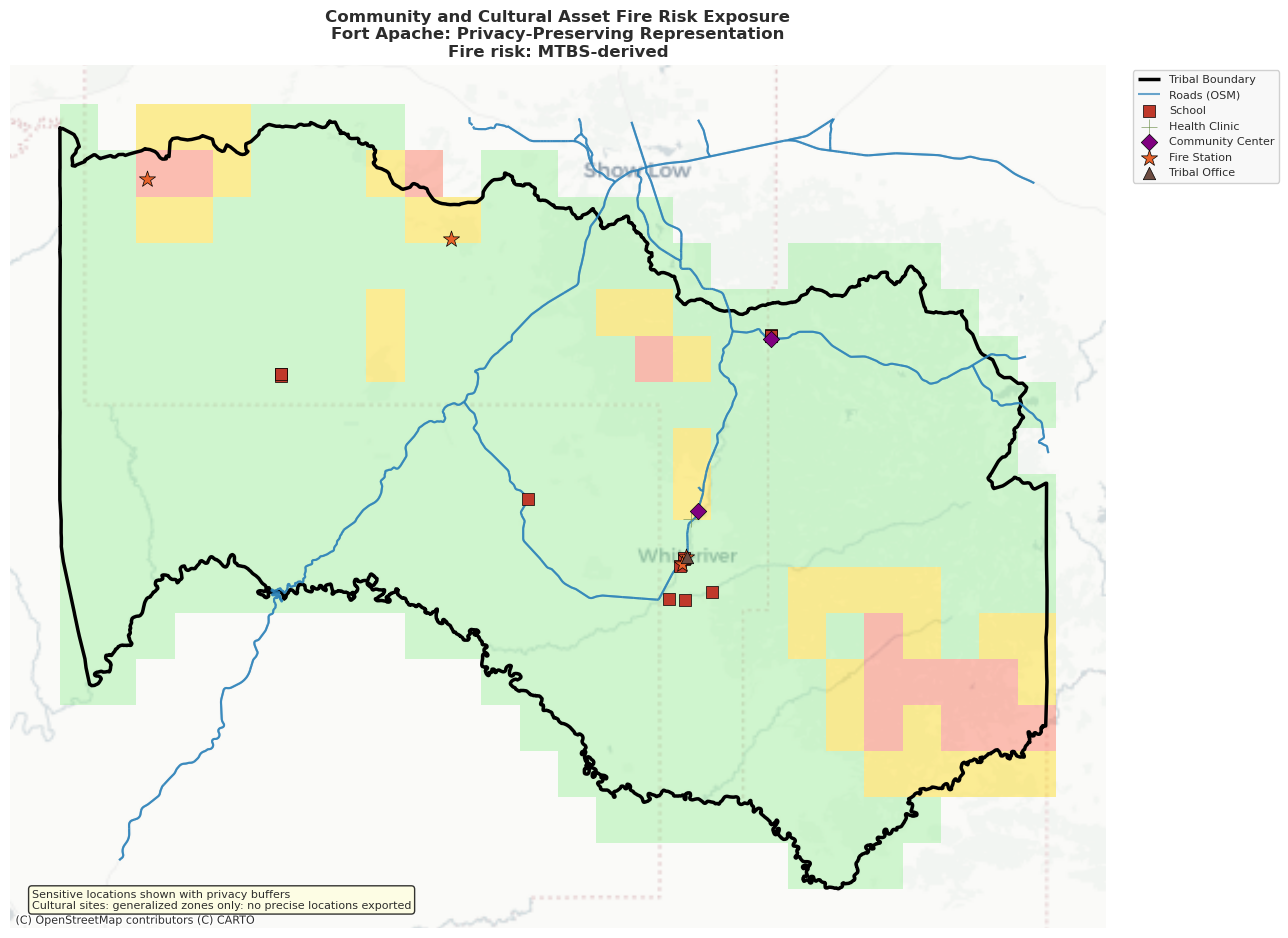

In [16]:
# Asset exposure map 
fig, ax = plt.subplots(figsize=(13, 11))

risk_colors = {"Low": "#90EE90", "Moderate": "#FFD700", "High": "#FF6347"}
for lvl, color in risk_colors.items():
    sub = fire_risk_grid[fire_risk_grid["risk_level"] == lvl]
    if not sub.empty:
        sub.to_crs(3857).plot(ax=ax, color=color, alpha=0.4, edgecolor="none", label=f"{lvl} Risk")

tribe_gdf.to_crs(3857).boundary.plot(
    ax=ax, color="black", linewidth=2.5, label="Tribal Boundary"
)

if not evacuation_routes.empty:
    evacuation_routes.to_crs(3857).plot(
        ax=ax, color=styles.SKY_BLUE, linewidth=1.5, alpha=0.7, label="Roads (OSM)", zorder=3
    )

# Public assets 
if not community_assets.empty:
    asset_style = {
        "School":          ("s", styles.EMBER_RED,   80),
        "Health Clinic":   ("+", styles.SAGE_GREEN,  120),
        "Community Center":("D", "purple",            70),
        "Fire Station":    ("*", styles.FIRE_ORANGE,  150),
        "Tribal Office":   ("^", styles.EARTH_BROWN,  80),
        "Water Tank":      ("o", "cyan",               60),
        "Other":           (".", styles.SMOKE_GRAY,   40),
    }
    for atype, (marker, color, size) in asset_style.items():
        sub = community_assets[community_assets["type"] == atype]
        if not sub.empty:
            sub.to_crs(3857).plot(
                ax=ax, marker=marker, color=color, markersize=size,
                edgecolor="black", linewidth=0.5, label=atype, zorder=5,
            )

# Sensitive areas (buffered)
if not community_buffered.empty and "buffered" in community_buffered.columns:
    sens = community_buffered[community_buffered.get("buffered", False) == True]
    if not sens.empty:
        sens.to_crs(3857).plot(
            ax=ax, color="gray", alpha=0.2,
            edgecolor="black", linewidth=0.8, linestyle="--",
            label="Sensitive Areas (buffered)", zorder=2,
        )

# Cultural aggregated zones
if not cultural_aggregated.empty:
    cultural_aggregated.to_crs(3857).plot(
        ax=ax, facecolor="none", edgecolor="magenta",
        linewidth=2, linestyle=":", hatch="///", alpha=0.4,
        label="Cultural Resource Zones (generalized)",
    )

try:
    ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)
except Exception:
    pass

ax.set_axis_off()
ax.set_title(
    f"Community and Cultural Asset Fire Risk Exposure\n"
    f"{TRIBE_OF_INTEREST}: Privacy-Preserving Representation"
    + ("\nFire risk: MTBS-derived" if MTBS_AVAILABLE else "\nFire risk: placeholder"),
    fontsize=12, fontweight="bold",
)
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), fontsize=8, framealpha=0.9)
ax.text(
    0.02, 0.02,
    "Sensitive locations shown with privacy buffers\n"
    "Cultural sites: generalized zones only: no precise locations exported",
    transform=ax.transAxes, fontsize=8, va="bottom",
    bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.8),
)
plt.tight_layout()
charts.save_figure(fig, "outputs/figures/community_asset_exposure_map.png")
plt.show()

Figure saved C:\Users\gekek\Documents\tfs_refactor\outputs\figures\fire_scenarios_impact.png


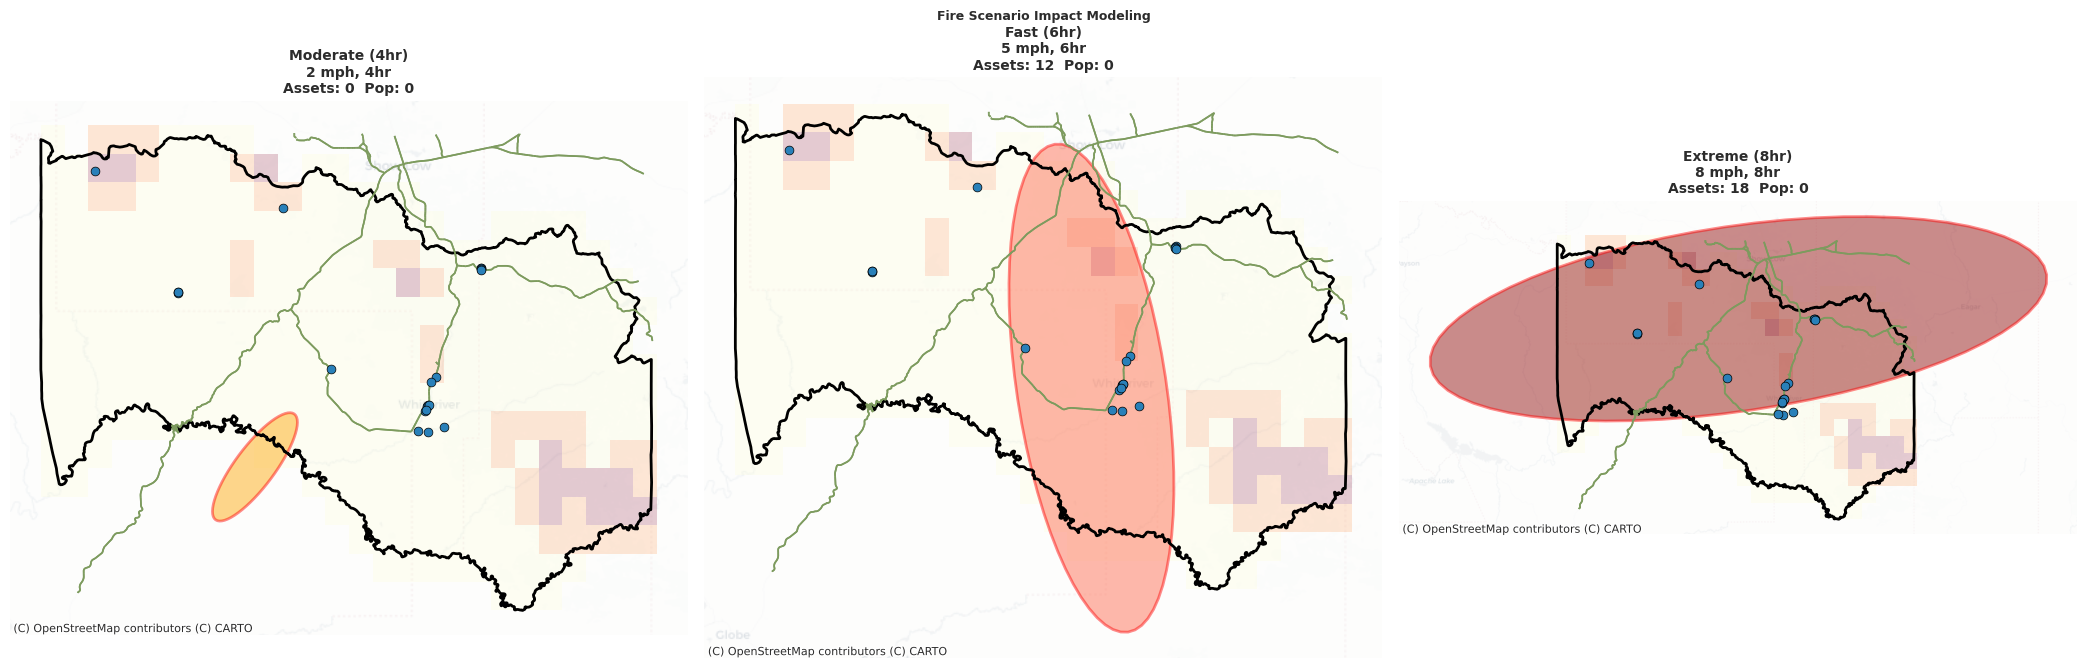

In [17]:
# Fire scenario maps
scenario_palette = ["#FFA500", "#FF6347", "#8B0000"]
n_scenarios = len(all_scenarios)
fig, axes = plt.subplots(1, n_scenarios, figsize=(n_scenarios * 7, 7))
if n_scenarios == 1:
    axes = [axes]

for idx, (ax, (_, scenario)) in enumerate(zip(axes, all_scenarios.iterrows())):
    tribe_gdf.to_crs(3857).boundary.plot(ax=ax, color="black", linewidth=2)
    fire_risk_grid.to_crs(3857).plot(
        ax=ax, column="risk_level", categorical=True,
        legend=False, alpha=0.2, cmap="YlOrRd",
    )
    gpd.GeoDataFrame(
        [scenario], geometry="geometry", crs=constants.CRS_GEOGRAPHIC
    ).to_crs(3857).plot(
        ax=ax, color=scenario_palette[idx], alpha=0.45,
        edgecolor="red", linewidth=2,
    )
    if not community_assets.empty:
        community_assets.to_crs(3857).plot(
            ax=ax, marker="o", color=styles.SKY_BLUE,
            markersize=40, zorder=4, edgecolor="black", linewidth=0.5,
        )
    if not evacuation_routes.empty:
        evacuation_routes.to_crs(3857).plot(
            ax=ax, color=styles.SAGE_GREEN, linewidth=1.2, zorder=3
        )
    try:
        ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, alpha=0.3)
    except Exception:
        pass
    impact = assess_scenario_impact(
        scenario.geometry, community_assets, evacuation_routes, cultural_sites
    )
    ax.set_title(
        f"{scenario['scenario_name']}\n"
        f"{scenario['spread_rate_mph']} mph, {scenario['duration_hours']}hr\n"
        f"Assets: {impact['assets_impacted']}  Pop: {impact['population_impacted']:,}",
        fontsize=10, fontweight="bold",
    )
    ax.set_axis_off()

plt.suptitle(
    "Fire Scenario Impact Modeling\n",
    fontsize=9, fontweight="bold",
)
plt.tight_layout()
charts.save_figure(fig, "outputs/figures/fire_scenarios_impact.png")
plt.show()

Figure saved C:\Users\gekek\Documents\tfs_refactor\outputs\figures\evacuation_route_vulnerability.png


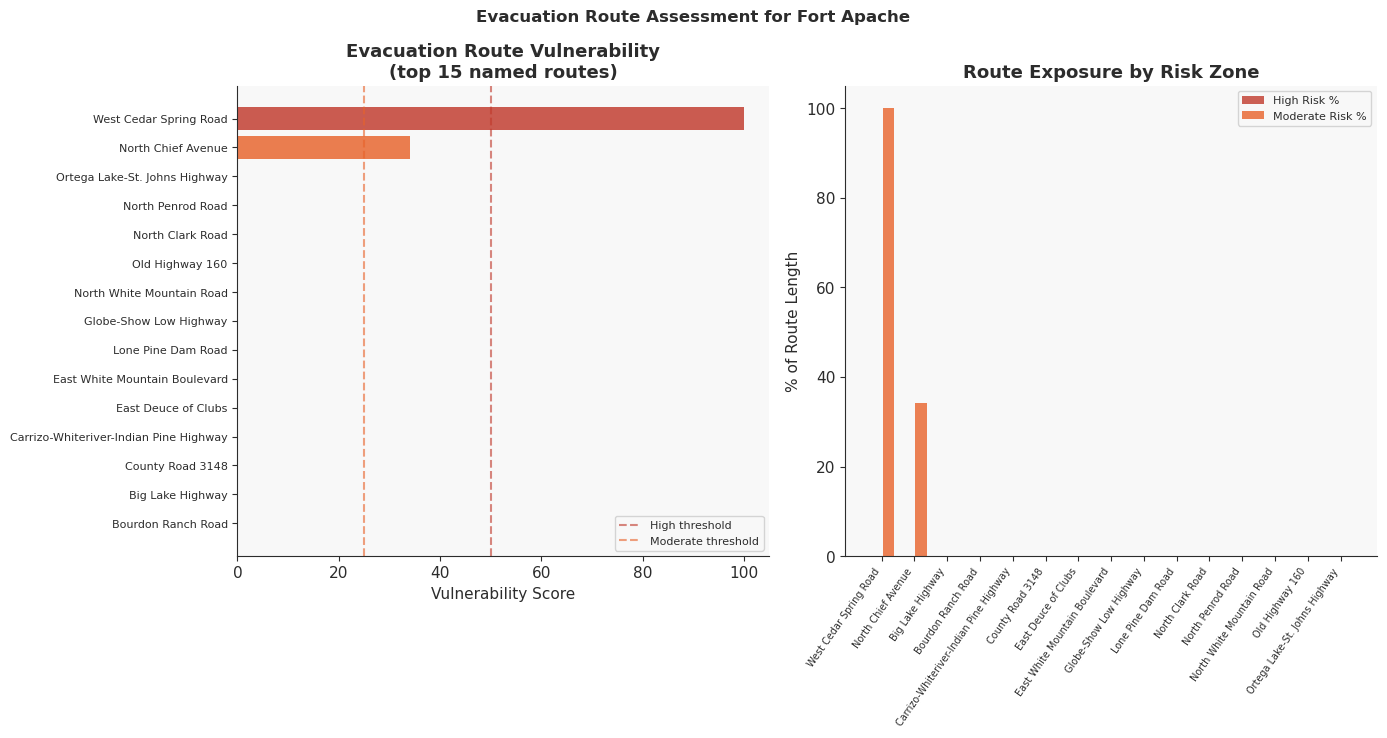

In [18]:
# Evacuation route vulnerability chart 
if not route_assessment.empty:
    # Normalize list-valued name column
    route_assessment["name"] = route_assessment["name"].apply(
        lambda v: v[0] if isinstance(v, list) else str(v)
    )

    # Aggregate individual OSM segments to named routes
    route_summary = (
        route_assessment.groupby("name")
        .agg(
            route_type=("route_type", "first"),
            total_km=("total_km", "sum"),
            high_risk_km=("high_risk_km", "sum"),
            moderate_risk_km=("moderate_risk_km", "sum"),
            capacity_vph=("capacity_vph", "first"),
        )
        .reset_index()
    )
    route_summary["high_risk_pct"]     = (route_summary["high_risk_km"]     / route_summary["total_km"] * 100).round(1)
    route_summary["moderate_risk_pct"] = (route_summary["moderate_risk_km"] / route_summary["total_km"] * 100).round(1)
    route_summary["vulnerability_score"] = (
        route_summary["high_risk_pct"] * 2 + route_summary["moderate_risk_pct"]
    ).round(1)

    # Cap at 15 for readability
    route_summary = route_summary.nlargest(15, "vulnerability_score")

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, max(6, len(route_summary) * 0.5)))

    s = route_summary.sort_values("vulnerability_score", ascending=True)
    ax1.barh(
        s["name"], s["vulnerability_score"],
        color=[
            styles.EMBER_RED   if v > 50 else
            styles.FIRE_ORANGE if v > 25 else
            styles.SAGE_GREEN  for v in s["vulnerability_score"]
        ],
        alpha=0.82,
    )
    ax1.axvline(50, color=styles.EMBER_RED,   linestyle="--", alpha=0.6, label="High threshold")
    ax1.axvline(25, color=styles.FIRE_ORANGE, linestyle="--", alpha=0.6, label="Moderate threshold")
    ax1.set_xlabel("Vulnerability Score")
    ax1.set_title("Evacuation Route Vulnerability\n(top 15 named routes)", fontweight="bold")
    ax1.tick_params(axis="y", labelsize=8)
    ax1.legend(fontsize=8)
    sns.despine(ax=ax1)

    s2 = route_summary.sort_values("high_risk_pct", ascending=False)
    x  = np.arange(len(s2))
    ax2.bar(x - 0.2, s2["high_risk_pct"],     0.35, label="High Risk %",     color=styles.EMBER_RED,   alpha=0.8)
    ax2.bar(x + 0.2, s2["moderate_risk_pct"], 0.35, label="Moderate Risk %", color=styles.FIRE_ORANGE, alpha=0.8)
    ax2.set_xticks(x)
    ax2.set_xticklabels(s2["name"], rotation=55, ha="right", fontsize=7)
    ax2.set_ylabel("% of Route Length")
    ax2.set_title("Route Exposure by Risk Zone", fontweight="bold")
    ax2.legend(fontsize=8)
    sns.despine(ax=ax2)

    plt.suptitle(f"Evacuation Route Assessment for {TRIBE_OF_INTEREST}",
                 fontsize=12, fontweight="bold")
    plt.tight_layout()
    charts.save_figure(fig, "outputs/figures/evacuation_route_vulnerability.png")
    plt.show()
else:
    print("No route assessment data to plot.")
    

## Privacy-compliant Exports

In [19]:
# Export public data only 
# Sensitive and highly sensitive data is NEVER exported with precise locations.

if not community_exposure.empty:
    public_exposure = community_exposure[
        community_exposure["privacy_level"] == "public"
    ].copy()
    public_exposure.to_csv(
        constants.OUTPUTS_DIR/"public_asset_exposure.csv", index=False
    )
    print("Exported to outputs/public_asset_exposure.csv")

if not route_assessment.empty:
    route_assessment.to_csv(
        constants.OUTPUTS_DIR / "evacuation_route_assessment.csv", index=False
    )
    print("Exported to outputs/evacuation_route_assessment.csv")

pd.DataFrame(scenario_impacts).to_csv(
    constants.OUTPUTS_DIR / "fire_scenario_impacts.csv", index=False
)
print("Exported to outputs/fire_scenario_impacts.csv")

# Aggregated summary JSON (no precise locations)
summary = {
    "analysis_date":        datetime.now().isoformat(),
    "tribe":                TRIBE_OF_INTEREST,
    "mtbs_fire_data":       MTBS_AVAILABLE,
    "public_assets":        len(community_assets[community_assets["privacy_level"] == "public"])
                            if not community_assets.empty else 0,
    "assets_high_risk":     int(community_exposure[community_exposure["risk_level"] == "High"].shape[0])
                            if not community_exposure.empty else 0,
    "cultural_sites":       "Not disclosed" if not cultural_sites.empty else "No data (consent not obtained)",
    "critical_routes":      int((route_assessment["vulnerability_score"] > 50).sum())
                            if not route_assessment.empty else 0,
}
with open(constants.OUTPUTS_DIR / "community_assets_summary.json", "w") as f:
    json.dump(summary, f, indent=2)
print("Exported to outputs/community_assets_summary.json")

print("\n")
print("SENSITIVE DATA NOT EXPORTED")
print("  Cultural site locations : PROTECTED")
print("  Sensitive asset locations: BUFFERED/AGGREGATED")
print("  All outputs comply with Tribal data sovereignty")

Exported to outputs/public_asset_exposure.csv
Exported to outputs/evacuation_route_assessment.csv
Exported to outputs/fire_scenario_impacts.csv
Exported to outputs/community_assets_summary.json


SENSITIVE DATA NOT EXPORTED
  Cultural site locations : PROTECTED
  Sensitive asset locations: BUFFERED/AGGREGATED
  All outputs comply with Tribal data sovereignty


## Summary and Findings

*(Fill in after running with real data.)*

Questions to address:
- Which asset types have the highest fire risk exposure, and how does that
  compare to the Tribal Nation's own fire management priorities?
- Do evacuation routes in high-risk zones have adequate capacity for the
  Tribal population? Are there coverage gaps?
- For the fire scenarios, which scenarios threaten critical infrastructure
  (health clinics, schools, water supply)?
- What are the limitations?
  - OSM infrastructure data may be incomplete; verify with Tribal GIS
  - Fire risk grid uses MTBS historical frequency, not fuel condition modeling
  - Elliptical fire scenarios are illustrative, not operational predictions
  - Cultural site analysis requires direct Tribal engagement
- Who should review these outputs? All outputs should be reviewed with
  Tribal emergency management, cultural preservation officers, and Tribal
  council before any external sharing or publication.

---
## References

In [20]:
print(generate_citations(["census_aiannh", "mtbs"]))

References/Data Sources
- Census TIGER AIANNH. US Census Bureau. https://www.census.gov/geographies/mapping-files/time-series/geo/tiger-line-file.html
- Monitoring Trends in Burn Severity (MTBS). USGS / USDA Forest Service. https://www.mtbs.gov
